In [1]:
import numpy as np
import scipy.stats
import pylab as plt
import random
def mc(f, normalization):
    
    return np.mean(f) * normalization
def f(x):
    for i in range(len(x)):
        x[i] = x[i]**3
    return np.array(x)


step: 100
step: 1000
step: 5000
step: 10000
step: 100000
step: 1000000
step: 10000000
step: 50000000
step: 100000000
MC integration result: [np.float64(39.80800444675488), np.float64(33.29203927658362), np.float64(31.30709363192534), np.float64(31.40475679360683), np.float64(32.267713710849506), np.float64(31.99962893565855), np.float64(31.999293551840324), np.float64(32.01198432403807), np.float64(31.99815349239566)]
2* sigma^4: 32


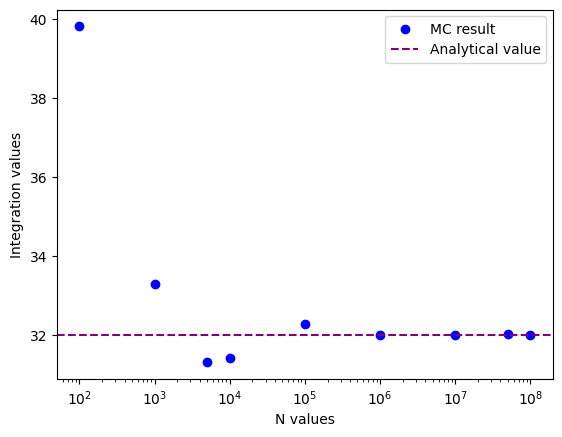

Error between the two, [ 7.80800445e+00  1.29203928e+00 -6.92906368e-01 -5.95243206e-01
  2.67713711e-01 -3.71064341e-04 -7.06448160e-04  1.19843240e-02
 -1.84650760e-03]


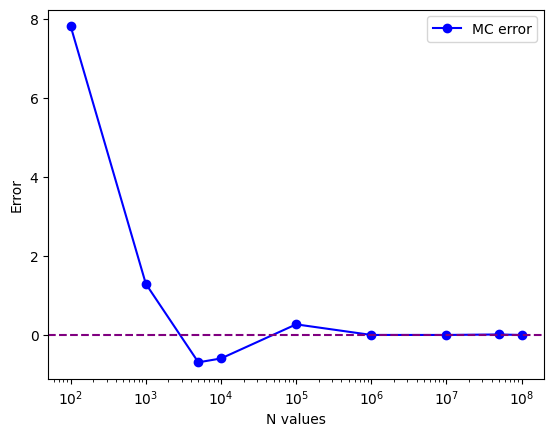

In [8]:
sigma = 2
analytical_value = 2*sigma**4

#N = np.linspace(10000, 10**7, 500000, dtype = int)
N = [100, 1000, 5000, 10000, 100000, 1000000, 10**7, 5*10**7, 10**8]

integration = []
normalization = np.sqrt(np.pi*sigma**2 / 2)
for i in range(len(N)):
    step = N[i]
    print("step:", step)
    #for i in range(step):
    #    p.append(np.abs(random.gauss(0,2))) #prendo così metà gaussiana
    p = np.abs(np.random.normal(0, 2, step))
    #print(f"i, N: {i}, {step}")
    """
    plt.hist(p, bins=30)
    plt.xlabel("random gaussian numbers")
    plt.title(f"Half gaussian for {step} step")
    plt.show()
    """
   
    
    #print("Sample standard deviation:", sigma)
    cube = f(p)
    integration.append(mc(cube, normalization))
print("MC integration result:", integration)
print("2* sigma^4:", analytical_value)
integration = np.array(integration)
plt.scatter(N, integration, label = 'MC result', color = 'blue')
plt.axhline(y= analytical_value, color='purple', linestyle='--', label="Analytical value")
plt.xlabel("N values")
plt.xscale('log')
plt.ylabel("Integration values")
plt.legend()
plt.show()
for i in range(len(integration)):
    error = integration - analytical_value
print(f"Error between the two, {integration-analytical_value}")
plt.plot(N, error, label = 'MC error', color = 'blue', marker = 'o')
plt.xlabel("N values")
plt.xscale('log')
plt.ylabel("Error")
plt.axhline(y= 0, color='purple', linestyle='--')
plt.legend()
plt.show()